![截圖 2025-09-23 晚上11.13.21.png](<attachment:截圖 2025-09-23 晚上11.13.21.png>)
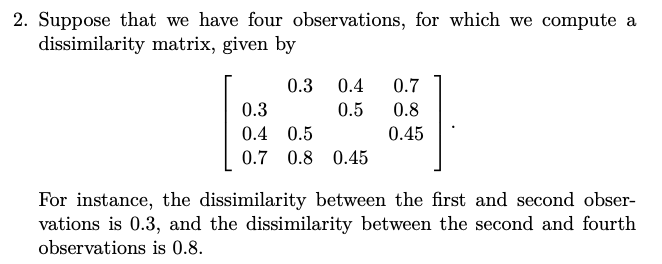

(a) On the basis of this dissimilarity matrix, sketch the dendrogram
that results from hierarchically clustering these four observations using complete linkage.</br>
Be sure to indicate on the plot the
height at which each fusion occurs, as well as the observations
corresponding to each leaf in the dendrogram.

In [ ]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

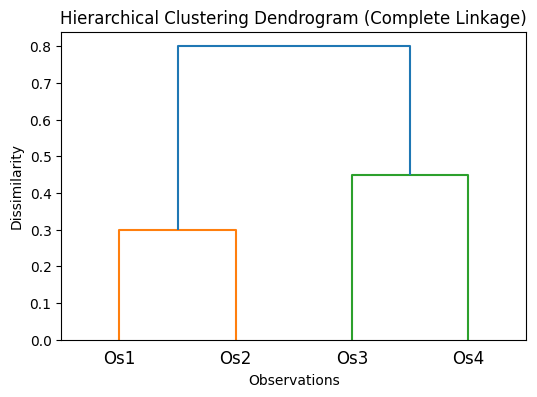

In [16]:
matrix = np.array([[0, 0.3, 0.4, 0.7], 
                   [0.3, 0, 0.5, 0.8], 
                   [0.4, 0.5, 0, 0.45], 
                   [0.7, 0.8, 0.45, 0]])
labels=["Os1", "Os2", "Os3", "Os4"]

condensed_matrix = squareform(matrix) # 把對稱矩陣轉換成「壓縮版的一維陣列」，只保留上三角（或下三角）的非對角元素。 符合 linkage()
complete_linkage_clustering = linkage(condensed_matrix, method='complete')

plt.figure(figsize=(6, 4))
dendrogram(complete_linkage_clustering,labels=labels)
plt.title("Hierarchical Clustering Dendrogram (Complete Linkage)")
plt.xlabel("Observations")
plt.ylabel("Dissimilarity")
plt.show()

(b) Repeat (a), this time using single linkage clustering.

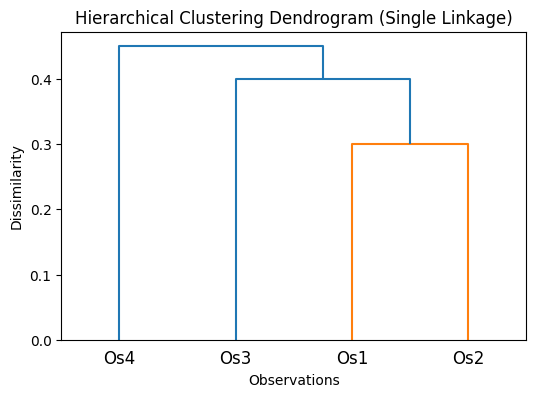

In [10]:
single_linkage_clustering = linkage(condensed_matrix, method='single')

plt.figure(figsize=(6, 4))
dendrogram(single_linkage_clustering, labels=["Os1", "Os2", "Os3", "Os4"])
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
plt.xlabel("Observations")
plt.ylabel("Dissimilarity")
plt.show()

(c) Suppose that we cut the dendrogram obtained in (a) such that two clusters result. Which observations are in each cluster?

In [ ]:
from scipy.cluster. hierarchy import \
(dendrogram ,
cut_tree )
from ISLP.cluster import compute_linkage
import pandas as pd


# (c) cut complete linkage into 2 clusters
clusters_complete = cut_tree(complete_linkage_clustering, n_clusters=2).reshape(-1)

# cut_tree() 的輸出形狀 會回傳一個 二維陣列，形狀是 (n_samples, 1) (4,1)-> reshape(-1) 的意思是「展平成一維向量」。(1,4)

print("Complete linkage, 2 clusters:")
print("Cluster 1:", [labels[i] for i in range(4) if clusters_complete[i] == 0])
print("Cluster 2:", [labels[i] for i in range(4) if clusters_complete[i] == 1])


Complete linkage, 2 clusters:
Cluster 1: ['Os1', 'Os2']
Cluster 2: ['Os3', 'Os4']


(d) Suppose that we cut the dendrogram obtained in (b) such that
two clusters result. Which observations are in each cluster?

In [18]:
# (d) cut single linkage into 2 clusters
clusters_single = cut_tree(single_linkage_clustering, n_clusters=2).reshape(-1)
print("Single linkage, 2 clusters:")
print("Cluster 1:", [labels[i] for i in range(4) if clusters_single[i] == 0])
print("Cluster 2:", [labels[i] for i in range(4) if clusters_single[i] == 1])

Single linkage, 2 clusters:
Cluster 1: ['Os1', 'Os2', 'Os3']
Cluster 2: ['Os4']


(e) It is mentioned in this chapter that at each fusion in the den-
drogram, the position of the two clusters being fused can be
swapped without changing the meaning of the dendrogram. Draw
a dendrogram that is equivalent to the dendrogram in (a), for
which two or more of the leaves are repositioned, but for which
the meaning of the dendrogram is the same.

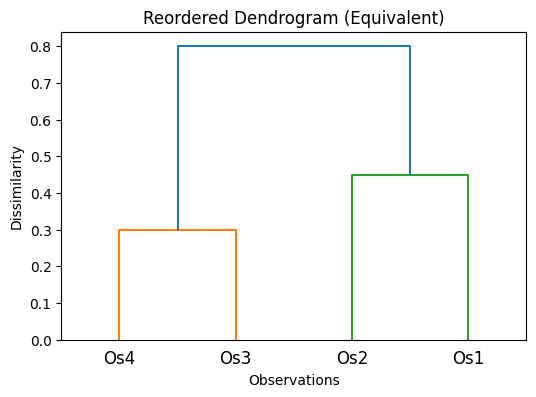

In [ ]:

plt.figure(figsize=(6, 4))
dendrogram(complete_linkage_clustering, labels=[ 'Os4', 'Os3','Os2', 'Os1']) #reposition the hierarchical clustering
plt.title("Reordered Dendrogram (Equivalent)")
plt.xlabel("Observations")
plt.ylabel("Dissimilarity")
plt.show()
